<a href="https://colab.research.google.com/github/MichalSlowakiewicz/Stochastic-Simulations/blob/master/Zadanie_4_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

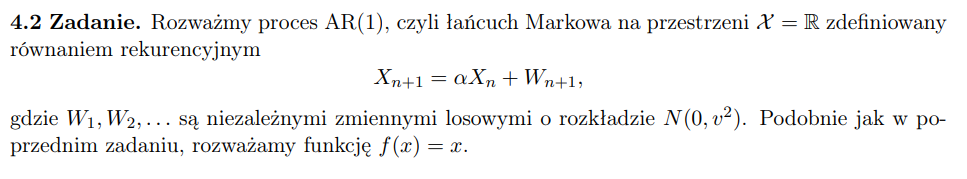

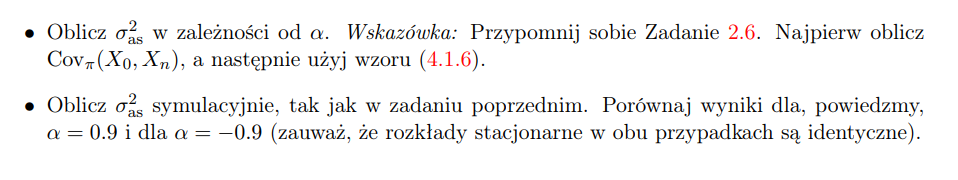

## Formula for $\sigma^2_{as}$
---
Let us recall that in Exercise 2.6 we compted the formulas for conditional distribution $X_n | X_0=x$ and stationary distribution $\pi$:

$$X_n | X_0 = x \sim N\left(\alpha^n x, \ v^2 \frac{1 - \alpha^{2n}}{1 - \alpha^2}\right)$$

$$\pi=N\left(0, \  \frac{v^2}{1 - \alpha^2}\right)$$

Let $X_0$ correspond to stationary distribution $X_0 \sim \mathcal{N}\left(0, \frac{v^2}{1-\alpha^2}\right)$. This implies that:

$$\mathbb{E}_\pi[X_0] = 0$$


$$\text{Var}_\pi(X_0) = \mathbb{E}_\pi[X_0^2] = \frac{v^2}{1-\alpha^2}$$

Then, the formula for covariance is as follows:

$$\text{Cov}_\pi(X_0, X_n) = \mathbb{E}_\pi[X_0 X_n] - \mathbb{E}_\pi[X_0]\mathbb{E}_\pi[X_n] = \mathbb{E}_\pi[X_0 X_n]$$

Now, we proceed with transformations:

$$\mathbb{E}[X_0 X_n] = \mathbb{E} \left[ \mathbb{E}[X_0 X_n | X_0] \right] = \mathbb{E} \left[ X_0 \cdot \mathbb{E}[X_n | X_0] \right]$$

Since we know the conditional distribution:


$$\mathbb{E} \left[ X_0 \cdot \mathbb{E}[X_n | X_0] \right] = \mathbb{E} \left[ X_0 \cdot (\alpha^n X_0) \right] = \alpha^n \mathbb{E}[X_0^2]$$


Finally, we obtain:

$$\text{Cov}_\pi(X_0, X_n) = \alpha^n \text{Var}_\pi(X_0)$$


Next, we will use the (4.1.6) formula:


$$\sigma^2_{as} = \text{Var}_\pi(X_0) + 2 \sum_{n=1}^\infty \text{Cov}_\pi(X_0, X_n)$$

$$\sigma^2_{as} = \text{Var}_\pi(X_0) + 2 \sum_{n=1}^\infty \alpha^n \text{Var}_\pi(X_0)$$

$$\sigma^2_{as} = \text{Var}_\pi(X_0) \left( 1 + 2 \sum_{n=1}^\infty \alpha^n \right)$$

$$1 + 2 \frac{\alpha}{1-\alpha} = \frac{1 - \alpha + 2\alpha}{1-\alpha} = \frac{1+\alpha}{1-\alpha}$$


$$\sigma^2_{as} = \frac{v^2}{1-\alpha^2} \cdot \frac{1+\alpha}{1-\alpha}$$

$$\sigma^2_{as} = \frac{v^2}{(1-\alpha)^2}$$

## Simulations
---

In [1]:
import numpy as np
import pandas as pd
import time

In [2]:
def theoretical_variance(alpha, v=1.0):
    var_pi = (v**2) / (1 - alpha**2)
    var_as = (v**2) / ((1 - alpha)**2)
    return var_pi, var_as

def simulate_ar1_mcmc(alpha, v=1.0, k=5000, m=1000):
    """Simulates k independent trajectories of length m."""

    # initializing from stationary distribution
    std_pi = np.sqrt((v**2) / (1 - alpha**2))
    current_states = np.random.normal(0, std_pi, size=k)

    # array for storing results
    path_sums = np.zeros(k)

    # loop for m timesteps
    for _ in range(m):
        # updating
        noise = np.random.normal(0, v, size=k)
        current_states = alpha * current_states + noise
        path_sums += current_states

    # mean for every trajectory
    trajectory_means = path_sums / m

    # asymptotic variance
    empirical_var_as = m * np.var(trajectory_means, ddof=1)

    return empirical_var_as

# simulation
v_val = 1.0
scenarios = [0.9, -0.9]
results = []

start_total = time.time()

for a in scenarios:
    var_pi, theo_var_as = theoretical_variance(a, v_val)
    emp_var_as = simulate_ar1_mcmc(a, v_val)

    results.append({
        "α": a,
        "Var_π": f"{var_pi:.4f}",
        "σ²_as (Theory)": f"{theo_var_as:.4f}",
        "σ²_as (Simulation)": f"{emp_var_as:.4f}"
    })

display(pd.DataFrame(results))

,α,Var_π,σ²_as (Theory),σ²_as (Simulation)
0,0.9,5.2632,100.0000,101.3505
1,-0.9,5.2632,0.2770,0.2832
